# Individual Notebook — Member3 (SVM + Logistic Regression)

**Module:** COM3032 / COMM074 — Practical Business Analytics
**Project:** Early Warning System for Student Dropout and Academic Success


This notebook is my individual submission for Sections 3 and 4 of the coursework. I train two models on the preprocessed data from our group notebook — SVM, which is my unique model, and Logistic Regression, which is the shared model that all team members train with their own hyperparameter configurations.
The approach here follows the CRISP-DM modelling phase. Rather than going straight to a final model, each algorithm goes through an iterative cycle: train a baseline, tune the hyperparameters, evaluate the results, identify what can be improved, and refine accordingly.

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, accuracy_score,
    roc_auc_score, roc_curve, auc
)

import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

## 2. Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Same folder structure as group notebook
PROJECT_DIR = '/content/drive/MyDrive/COMM074_Project'
PREPROCESSED_DIR = os.path.join(PROJECT_DIR, 'preprocessed')

# Load preprocessed train and test sets from group notebook
train_data = pd.read_csv(os.path.join(PREPROCESSED_DIR, 'train_preprocessed.csv'))
test_data = pd.read_csv(os.path.join(PREPROCESSED_DIR, 'test_preprocessed.csv'))

# Separate features from target
X_train = train_data.drop(columns=['target'])
y_train = train_data['target']
X_test = test_data.drop(columns=['target'])
y_test = test_data['target']

print(f'Train: {X_train.shape} | Test: {X_test.shape}')
print(f'Classes: {dict(y_train.value_counts().sort_index())}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: (3539, 71) | Test: (885, 71)
Classes: {0: np.int64(1137), 1: np.int64(635), 2: np.int64(1767)}


## 3. Scaling

The preprocessed data from the group notebook is saved without scaling, since some models in the team (Decision Tree, AdaBoost) do not require it. SVM, however, is distance-based, so features with larger numerical ranges would disproportionately influence the model if left unscaled. The scaler is fitted on the training data only and then applied to the test set to prevent any data leakage.

In [ ]:
# Fit scaler on training data, transform both sets
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns, index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns, index=X_test.index
)

## 4. SVM

Went with SVM because it works well when you've got a lot of features which we do — 71 after encoding. It basically looks for the widest gap it can find between the classes and only really pays attention to the data points sitting close to that gap. RBF kernel because the connection between stuff like tuition status, age, grades and dropping out is unlikely to be a simple straight line.

Biggest weakness is you can't really explain what it's doing. A decision tree can say "this student was flagged because X" but SVM can't do that.

### 4.1 Baseline

In [ ]:
# Default SVM — no class weighting, default C and gamma
# Gives us a reference point to measure how much tuning helps
svm_baseline = SVC(random_state=42)
svm_baseline.fit(X_train_scaled, y_train)
y_pred_svm_base = svm_baseline.predict(X_test_scaled)

print(f'Accuracy:          {accuracy_score(y_test, y_pred_svm_base):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_svm_base):.4f}')
print(f'Macro F1:          {f1_score(y_test, y_pred_svm_base, average="macro"):.4f}')
print(f'Weighted F1:       {f1_score(y_test, y_pred_svm_base, average="weighted"):.4f}')

Accuracy:          0.6181
Balanced Accuracy: 0.5001
Macro F1:          0.4871
Weighted F1:       0.5795


### 4.2 Hyperparameter Tuning

The baseline doesn't do anything about class imbalance so it's probably just defaulting to Graduate most of the time since that's the biggest group. The grid search tries different combinations of C (how tightly it fits the training data), gamma (how far each point's influence reaches — smaller means smoother boundaries), and class_weight (whether to penalise mistakes on the smaller classes more). Using balanced accuracy to score because regular accuracy would just reward a model that predicts Graduate for everyone.

In [ ]:
# Grid over C, gamma, and class weighting
param_grid = {
    'C': [0.5, 1, 5, 10],
    'gamma': ['scale', 0.005, 0.01],
    'class_weight': ['balanced', None],
}

# 5-fold stratified cross-validation
svm_grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    param_grid, cv=5, scoring='balanced_accuracy',
    n_jobs=-1, verbose=1, refit=True
)
svm_grid.fit(X_train_scaled, y_train)

print(f'Best params: {svm_grid.best_params_}')
print(f'Best CV score: {svm_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'C': 1, 'class_weight': 'balanced', 'gamma': 0.01}
Best CV score: 0.5824


### 4.3 Cross-Validation Fold Analysis

Not just looking at the best score but checking how stable the model is across folds. If the scores vary a lot between folds the model is unreliable — a low standard deviation means it's consistent regardless of which data it's trained on.

Fold scores: ['0.5906', '0.5829', '0.5777', '0.5766', '0.5839']
Mean: 0.5824
Std:  0.0050


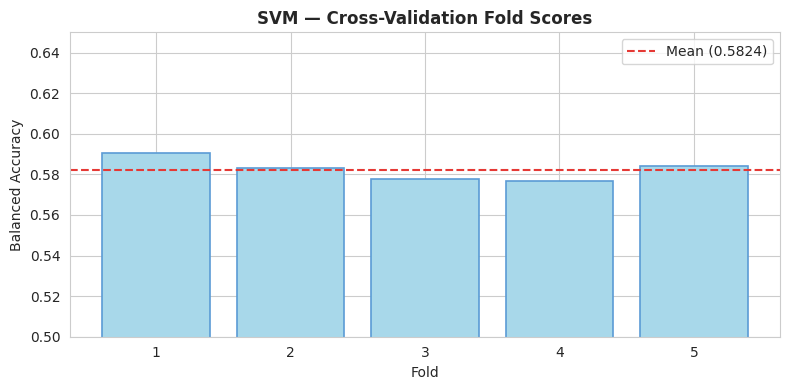

In [ ]:
# Extract per-fold scores for the best parameter combination
cv_results = pd.DataFrame(svm_grid.cv_results_)
best_idx = svm_grid.best_index_
fold_scores = [cv_results[f'split{i}_test_score'].iloc[best_idx] for i in range(5)]

print(f'Fold scores: {[f"{s:.4f}" for s in fold_scores]}')
print(f'Mean: {np.mean(fold_scores):.4f}')
print(f'Std:  {np.std(fold_scores):.4f}')

# Visualise fold scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 6), fold_scores, color='#A8D8EA', edgecolor='#5B9BD5', linewidth=1.2)
ax.axhline(y=np.mean(fold_scores), color='#E53935', linestyle='--', linewidth=1.5, label=f'Mean ({np.mean(fold_scores):.4f})')
ax.set_xlabel('Fold')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('SVM — Cross-Validation Fold Scores', fontweight='bold')
ax.set_xticks(range(1, 6))
ax.legend()
ax.set_ylim(0.5, 0.65)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'svm_cv_folds.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.4 Grid Search Results

Visualising the full grid search rather than just the best result. The heatmap shows balanced accuracy for every C and gamma combination (with balanced class weights since that's what the search picked).

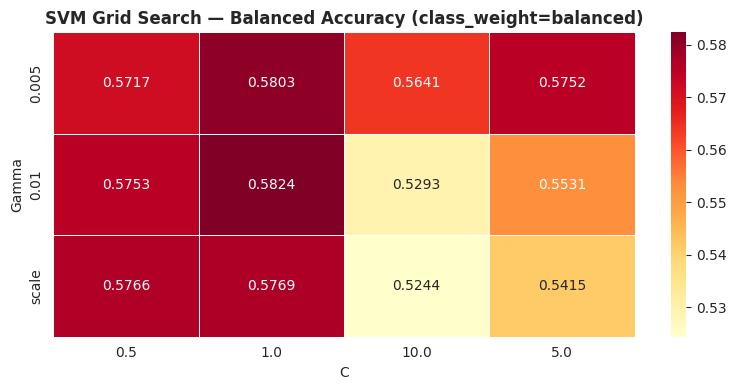

In [ ]:
# Filter results to balanced class_weight only and pivot into heatmap
cv_df = pd.DataFrame(svm_grid.cv_results_)
balanced_mask = cv_df['param_class_weight'] == 'balanced'
balanced_df = cv_df[balanced_mask].copy()

# Build pivot table
balanced_df['C'] = balanced_df['param_C'].astype(str)
balanced_df['gamma'] = balanced_df['param_gamma'].astype(str)
heatmap_data = balanced_df.pivot_table(values='mean_test_score', index='gamma', columns='C')

fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, linecolor='white')
ax.set_title('SVM Grid Search — Balanced Accuracy (class_weight=balanced)', fontweight='bold')
ax.set_xlabel('C')
ax.set_ylabel('Gamma')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'svm_gridsearch_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.5 Tuned SVM Results

In [ ]:
# Evaluate best model on test set
svm_best = svm_grid.best_estimator_
y_pred_svm = svm_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_svm, target_names=['Dropout', 'Enrolled', 'Graduate']))
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_svm):.4f}')
print(f'Macro F1:          {f1_score(y_test, y_pred_svm, average="macro"):.4f}')

              precision    recall  f1-score   support

     Dropout       0.67      0.57      0.61       284
    Enrolled       0.34      0.53      0.42       159
    Graduate       0.72      0.64      0.68       442

    accuracy                           0.60       885
   macro avg       0.58      0.58      0.57       885
weighted avg       0.63      0.60      0.61       885

Balanced Accuracy: 0.5825
Macro F1:          0.5707


### 4.6 Confusion Matrix

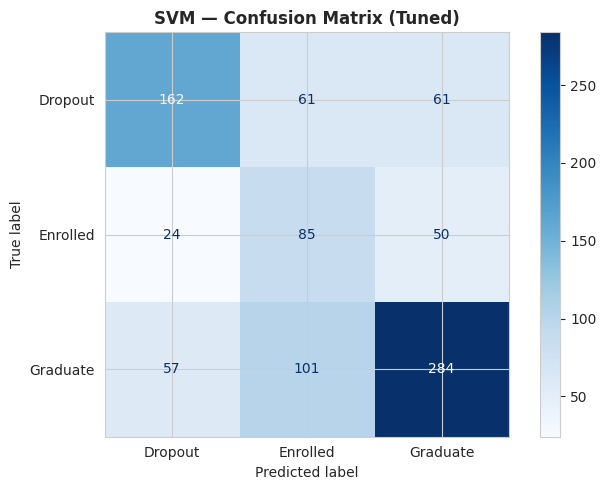

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_svm = confusion_matrix(y_test, y_pred_svm)
ConfusionMatrixDisplay(cm_svm, display_labels=['Dropout','Enrolled','Graduate']).plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('SVM — Confusion Matrix (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'svm_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

### 4.7 Improvement from Tuning

In [ ]:
# Compare baseline vs tuned
svm_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'Baseline': [
        accuracy_score(y_test, y_pred_svm_base),
        balanced_accuracy_score(y_test, y_pred_svm_base),
        f1_score(y_test, y_pred_svm_base, average='macro'),
        f1_score(y_test, y_pred_svm_base, average='weighted')],
    'Tuned': [
        accuracy_score(y_test, y_pred_svm),
        balanced_accuracy_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm, average='macro'),
        f1_score(y_test, y_pred_svm, average='weighted')]
})
svm_comparison['Change'] = svm_comparison['Tuned'] - svm_comparison['Baseline']
print(svm_comparison.set_index('Metric').round(4).to_string())

                   Baseline   Tuned  Change
Metric                                     
Accuracy             0.6181  0.6000 -0.0181
Balanced Accuracy    0.5001  0.5825  0.0824
Macro F1             0.4871  0.5707  0.0836
Weighted F1          0.5795  0.6114  0.0319


### 4.8 Learning Curve

Checking whether the model would benefit from more data or if it's hit a ceiling. If training and validation scores converge the model has learnt what it can from this feature set. If there's still a gap, more data might help.

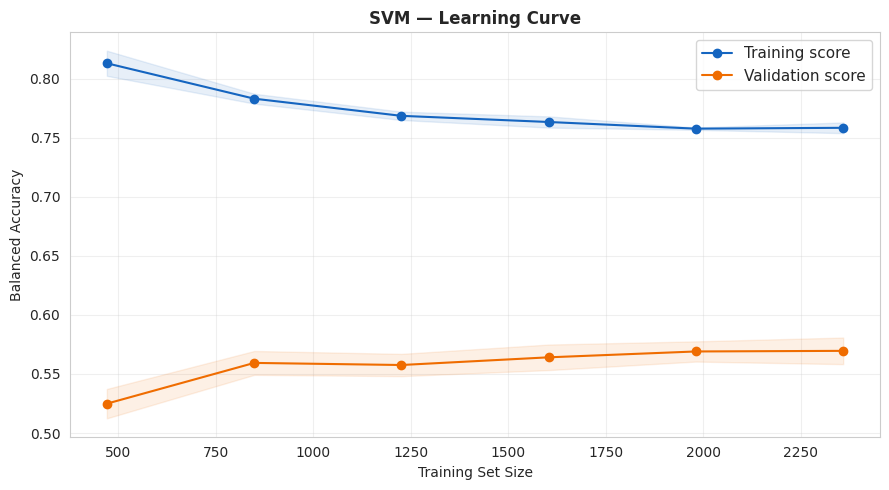

In [ ]:
# Generate learning curve with increasing training sizes
train_sizes, train_scores, val_scores = learning_curve(
    SVC(**svm_grid.best_params_, kernel='rbf', random_state=42),
    X_train_scaled, y_train, cv=3, scoring='balanced_accuracy',
    train_sizes=np.linspace(0.2, 1.0, 6), n_jobs=-1
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='#1565C0', label='Training score')
ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='#1565C0')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='#EF6C00', label='Validation score')
ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='#EF6C00')
ax.set_xlabel('Training Set Size')
ax.set_ylabel('Balanced Accuracy')
ax.set_title('SVM — Learning Curve', fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'svm_learning_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

## 5. Logistic Regression (Shared Baseline)

We all train Logistic Regression in our individual notebooks but everyone uses different settings. I started with saga solver and C=0.5. LR makes a good shared baseline — it's quick to run, gives you actual probabilities rather than just a class label, and you can look at the coefficients to see what's driving the predictions. So if the university wants to know why a student was flagged we can actually point to specific factors, which you can't do with SVM.

### 5.1 Baseline

In [ ]:
# My starting config: saga solver, C=0.5, no class weighting
lr_baseline = LogisticRegression(C=0.5, solver='saga', max_iter=2000, random_state=42)
lr_baseline.fit(X_train_scaled, y_train)
y_pred_lr_base = lr_baseline.predict(X_test_scaled)

print(f'Accuracy:          {accuracy_score(y_test, y_pred_lr_base):.4f}')
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_lr_base):.4f}')
print(f'Macro F1:          {f1_score(y_test, y_pred_lr_base, average="macro"):.4f}')
print(f'Weighted F1:       {f1_score(y_test, y_pred_lr_base, average="weighted"):.4f}')

Accuracy:          0.6271
Balanced Accuracy: 0.5195
Macro F1:          0.5162
Weighted F1:       0.6005


### 5.2 Hyperparameter Tuning

Tuning C and solver, and also letting the grid decide whether balanced class weights help.

In [ ]:
# Grid over C, solver, and class weighting
lr_param_grid = {
    'C': [0.001, 0.01, 0.05, 0.1, 0.5, 1],
    'solver': ['saga', 'lbfgs'],
    'class_weight': ['balanced', None],
    'max_iter': [3000],
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    lr_param_grid, cv=5, scoring='balanced_accuracy',
    n_jobs=-1, verbose=1, refit=True
)
lr_grid.fit(X_train_scaled, y_train)

print(f'Best params: {lr_grid.best_params_}')
print(f'Best CV score: {lr_grid.best_score_:.4f}')

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'C': 0.01, 'class_weight': 'balanced', 'max_iter': 3000, 'solver': 'saga'}
Best CV score: 0.5778


### 5.3 Tuned LR Results

In [ ]:
# Evaluate best LR on test set
lr_best = lr_grid.best_estimator_
y_pred_lr = lr_best.predict(X_test_scaled)

print(classification_report(y_test, y_pred_lr, target_names=['Dropout', 'Enrolled', 'Graduate']))
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred_lr):.4f}')
print(f'Macro F1:          {f1_score(y_test, y_pred_lr, average="macro"):.4f}')

              precision    recall  f1-score   support

     Dropout       0.67      0.56      0.61       284
    Enrolled       0.29      0.52      0.37       159
    Graduate       0.72      0.59      0.65       442

    accuracy                           0.57       885
   macro avg       0.56      0.56      0.54       885
weighted avg       0.63      0.57      0.59       885

Balanced Accuracy: 0.5573
Macro F1:          0.5447


### 5.4 Confusion Matrix

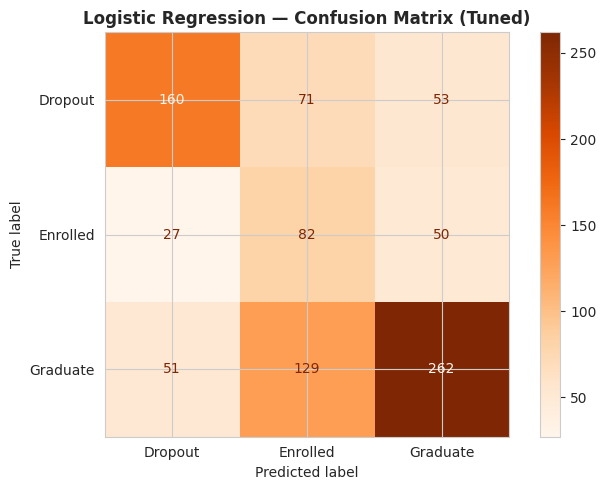

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr, display_labels=['Dropout','Enrolled','Graduate']).plot(ax=ax, cmap='Oranges', values_format='d')
ax.set_title('Logistic Regression — Confusion Matrix (Tuned)', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'lr_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Improvement from Tuning

In [ ]:
# LR baseline vs tuned — same format as SVM for consistency
lr_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'Baseline': [
        accuracy_score(y_test, y_pred_lr_base),
        balanced_accuracy_score(y_test, y_pred_lr_base),
        f1_score(y_test, y_pred_lr_base, average='macro'),
        f1_score(y_test, y_pred_lr_base, average='weighted')],
    'Tuned': [
        accuracy_score(y_test, y_pred_lr),
        balanced_accuracy_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_lr, average='weighted')]
})
lr_comparison['Change'] = lr_comparison['Tuned'] - lr_comparison['Baseline']
print(lr_comparison.set_index('Metric').round(4).to_string())

                   Baseline   Tuned  Change
Metric                                     
Accuracy             0.6271  0.5695 -0.0576
Balanced Accuracy    0.5195  0.5573  0.0378
Macro F1             0.5162  0.5447  0.0285
Weighted F1          0.6005  0.5878 -0.0127


### 5.6 LR Feature Importance

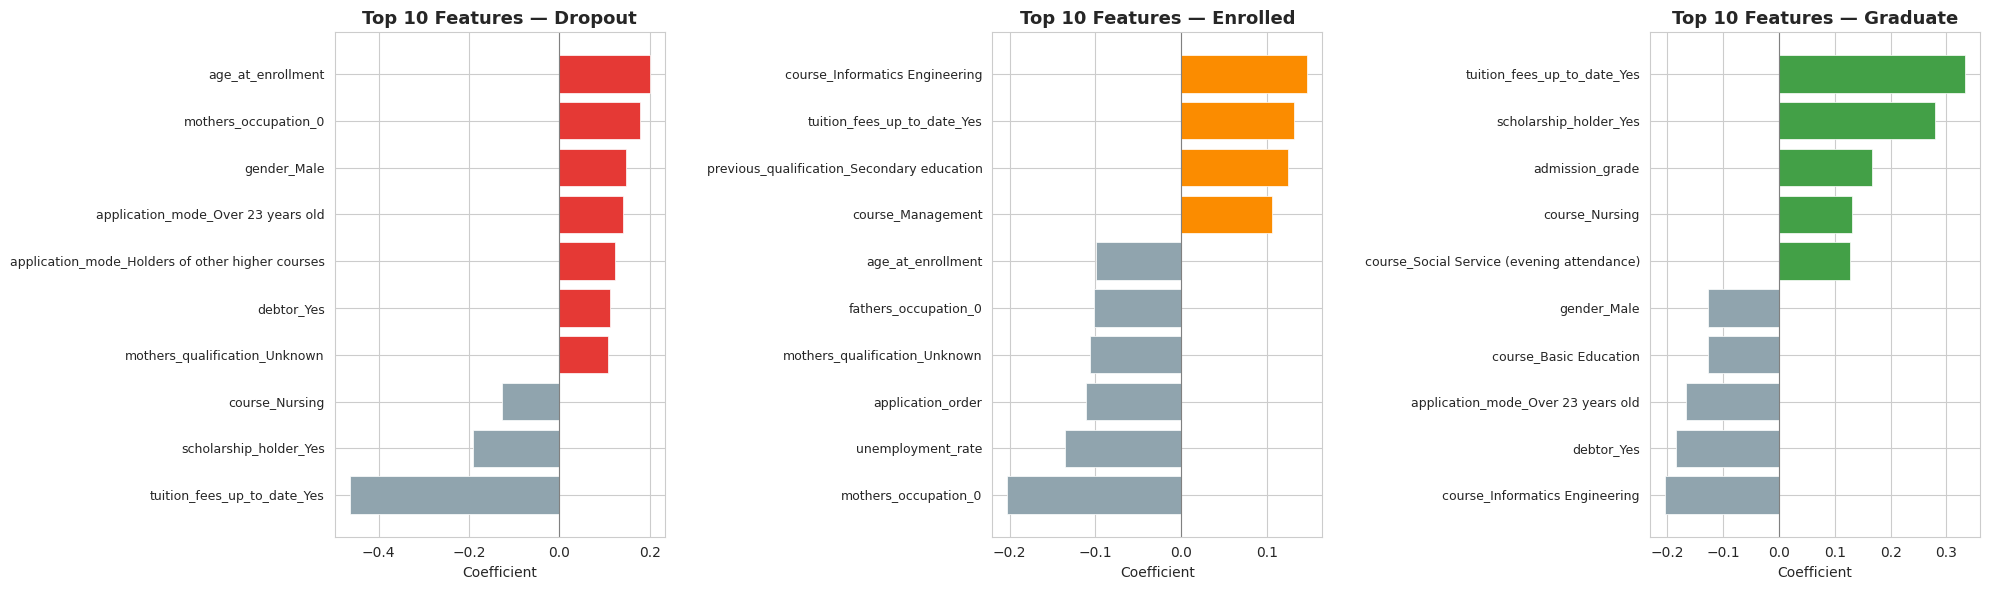

In [ ]:
# Top 10 coefficients per class — shows what's driving each prediction
feature_names = X_train.columns
classes = ['Dropout', 'Enrolled', 'Graduate']
class_colors = ['#E53935', '#FB8C00', '#43A047']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, cls in enumerate(classes):
    coefs = lr_best.coef_[i]
    top_idx = np.argsort(np.abs(coefs))[-10:]
    sorted_order = np.argsort(coefs[top_idx])
    top_idx = top_idx[sorted_order]

    axes[i].barh(range(10), coefs[top_idx],
                 color=[class_colors[i] if c > 0 else '#90A4AE' for c in coefs[top_idx]],
                 edgecolor='white', linewidth=0.5)
    axes[i].set_yticks(range(10))
    axes[i].set_yticklabels(feature_names[top_idx], fontsize=9)
    axes[i].set_title(f'Top 10 Features — {cls}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Coefficient')
    axes[i].axvline(x=0, color='grey', linewidth=0.8)

plt.tight_layout(w_pad=3)
plt.savefig(os.path.join(PROJECT_DIR, 'lr_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

For Dropout, age is the biggest factor pushing students towards dropping out — older students are more at risk. Being male, applying through the over-23 route, and having debt all point the same way. The biggest thing working against dropout is tuition fees being up to date (strongest negative coefficient by far), followed by having a scholarship. We saw both of these in the EDA so it checks out.

Enrolled is the hardest one to read which kind of makes sense since these students are in the middle — they haven't graduated or dropped out yet. Some specific courses and application modes show up but nothing as dominant as the financial stuff in the other two classes. Unemployment rate has a negative effect here which is interesting, maybe students in a bad economy either push through and graduate or leave entirely rather than hanging around.

Graduate is almost a mirror of Dropout. Tuition fees and scholarship are the two strongest positive factors — students who are financially sorted are way more likely to finish. Admission grade helps too. Debt and being male both reduce the chances of graduating, same pattern we've been seeing throughout.

The thing that stands out across all three is money. Tuition fees, scholarships, debt — they keep showing up no matter which class you look at. If a university wanted one thing to keep an eye on for early intervention, whether a student is falling behind on payments would be it.

## 6. Model Comparison

In [ ]:
# Side by side metrics
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Balanced Accuracy', 'Macro F1', 'Weighted F1'],
    'SVM': [accuracy_score(y_test, y_pred_svm), balanced_accuracy_score(y_test, y_pred_svm),
            f1_score(y_test, y_pred_svm, average='macro'), f1_score(y_test, y_pred_svm, average='weighted')],
    'Logistic Regression': [accuracy_score(y_test, y_pred_lr), balanced_accuracy_score(y_test, y_pred_lr),
            f1_score(y_test, y_pred_lr, average='macro'), f1_score(y_test, y_pred_lr, average='weighted')],
})
comparison['Better'] = comparison.apply(lambda r: 'SVM' if r['SVM'] > r['Logistic Regression'] else 'LR', axis=1)
print(comparison.set_index('Metric').round(4).to_string())

                      SVM  Logistic Regression Better
Metric                                               
Accuracy           0.6000               0.5695    SVM
Balanced Accuracy  0.5825               0.5573    SVM
Macro F1           0.5707               0.5447    SVM
Weighted F1        0.6114               0.5878    SVM


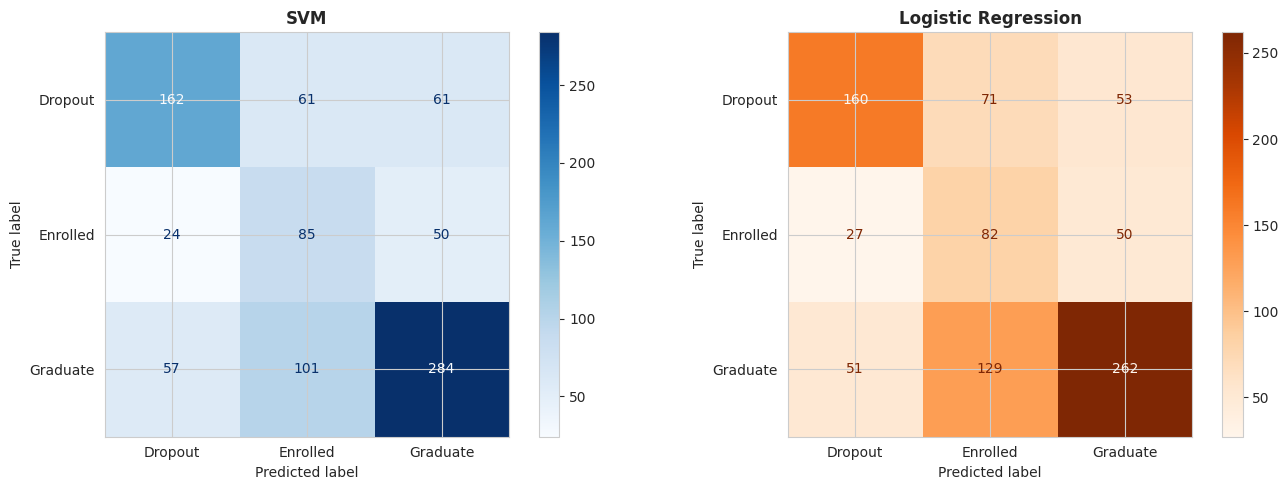

In [ ]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ConfusionMatrixDisplay(cm_svm, display_labels=['Dropout','Enrolled','Graduate']).plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('SVM', fontweight='bold')
ConfusionMatrixDisplay(cm_lr, display_labels=['Dropout','Enrolled','Graduate']).plot(ax=axes[1], cmap='Oranges', values_format='d')
axes[1].set_title('Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'model_comparison_cm.png'), dpi=150, bbox_inches='tight')
plt.show()

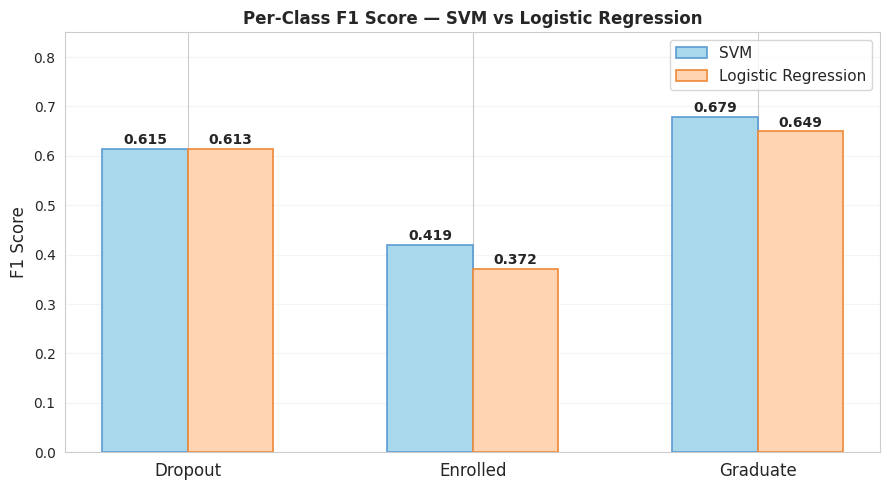

In [ ]:
# Per-class F1 comparison
f1_svm = f1_score(y_test, y_pred_svm, average=None)
f1_lr = f1_score(y_test, y_pred_lr, average=None)
classes = ['Dropout', 'Enrolled', 'Graduate']

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(3)
ax.bar(x - 0.15, f1_svm, 0.3, label='SVM', color='#A8D8EA', edgecolor='#5B9BD5', linewidth=1.2)
ax.bar(x + 0.15, f1_lr, 0.3, label='Logistic Regression', color='#FFD4B2', edgecolor='#ED8936', linewidth=1.2)
for i in range(3):
    ax.text(x[i]-0.15, f1_svm[i]+0.01, f'{f1_svm[i]:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(x[i]+0.15, f1_lr[i]+0.01, f'{f1_lr[i]:.3f}', ha='center', fontsize=10, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, fontsize=12)
ax.set_ylabel('F1 Score', fontsize=12)
ax.set_title('Per-Class F1 Score — SVM vs Logistic Regression', fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.85)
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'per_class_f1.png'), dpi=150, bbox_inches='tight')
plt.show()

Both models are best at predicting Graduate and worst at Enrolled. Graduate is the biggest class with the clearest pattern so that's expected. Enrolled is the tricky one — those students could go either way so there's not much for the model to latch onto. Dropout is pretty close between the two. SVM beats LR across all three classes but the biggest gap is on Enrolled, probably because the RBF kernel picks up some non-linear patterns that LR can't.

### 6.1 ROC-AUC Curves

ROC curves show the trade-off between true positive rate and false positive rate at different thresholds. AUC gives a single number summary — 0.5 means random guessing, 1.0 means perfect. This is a better measure of how well the model separates the classes than accuracy alone.

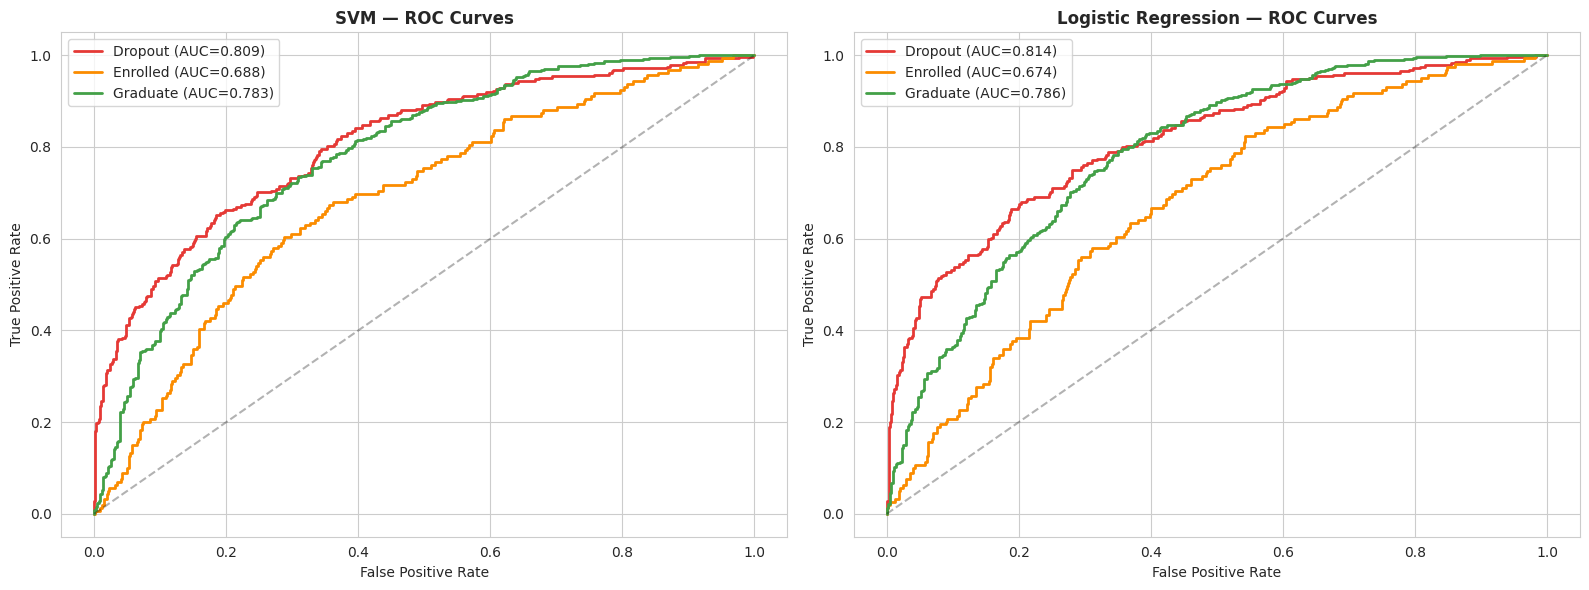

SVM Macro ROC-AUC:  0.7603
LR Macro ROC-AUC:   0.7580


In [ ]:
# Need probability outputs for ROC — retrain SVM with probability=True
svm_prob = SVC(**svm_grid.best_params_, kernel='rbf', random_state=42, probability=True)
svm_prob.fit(X_train_scaled, y_train)
y_prob_svm = svm_prob.predict_proba(X_test_scaled)

# LR already has predict_proba
y_prob_lr = lr_best.predict_proba(X_test_scaled)

# Binarize target for multi-class ROC
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_names = ['Dropout', 'Enrolled', 'Graduate']
class_colors = ['#E53935', '#FB8C00', '#43A047']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# SVM ROC
for i, (name, color) in enumerate(zip(class_names, class_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc_val:.3f})')
axes[0].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('SVM — ROC Curves', fontweight='bold')
axes[0].legend(fontsize=10)

# LR ROC
for i, (name, color) in enumerate(zip(class_names, class_colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC={roc_auc_val:.3f})')
axes[1].plot([0,1], [0,1], 'k--', alpha=0.3)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Logistic Regression — ROC Curves', fontweight='bold')
axes[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

# Overall macro AUC
svm_auc = roc_auc_score(y_test_bin, y_prob_svm, multi_class='ovr', average='macro')
lr_auc = roc_auc_score(y_test_bin, y_prob_lr, multi_class='ovr', average='macro')
print(f'SVM Macro ROC-AUC:  {svm_auc:.4f}')
print(f'LR Macro ROC-AUC:   {lr_auc:.4f}')

## 7. Cross-Group Comparison

In [ ]:
# Placeholder — fill in once teammates share their results
# all_results = pd.DataFrame({
#     'Member': ['Mahi', 'Vinayak', 'Pavan', 'Neha', 'Azad'],
#     'Model': ['Decision Tree', 'kNN', 'AdaBoost/LDA', 'SVM', 'Naive Bayes'],
#     'Macro F1': [0.0, 0.0, 0.0, f1_score(y_test, y_pred_svm, average='macro'), 0.0],
#     'Bal Acc': [0.0, 0.0, 0.0, balanced_accuracy_score(y_test, y_pred_svm), 0.0],
# })

print('My results:')
print(f'  SVM —  Macro F1: {f1_score(y_test, y_pred_svm, average="macro"):.4f} | Bal Acc: {balanced_accuracy_score(y_test, y_pred_svm):.4f} | ROC-AUC: {svm_auc:.4f}')
print(f'  LR  —  Macro F1: {f1_score(y_test, y_pred_lr, average="macro"):.4f} | Bal Acc: {balanced_accuracy_score(y_test, y_pred_lr):.4f} | ROC-AUC: {lr_auc:.4f}')

My results:
  SVM —  Macro F1: 0.5707 | Bal Acc: 0.5825 | ROC-AUC: 0.7603
  LR  —  Macro F1: 0.5447 | Bal Acc: 0.5573 | ROC-AUC: 0.7580


## 8. Model Predictions Visualised

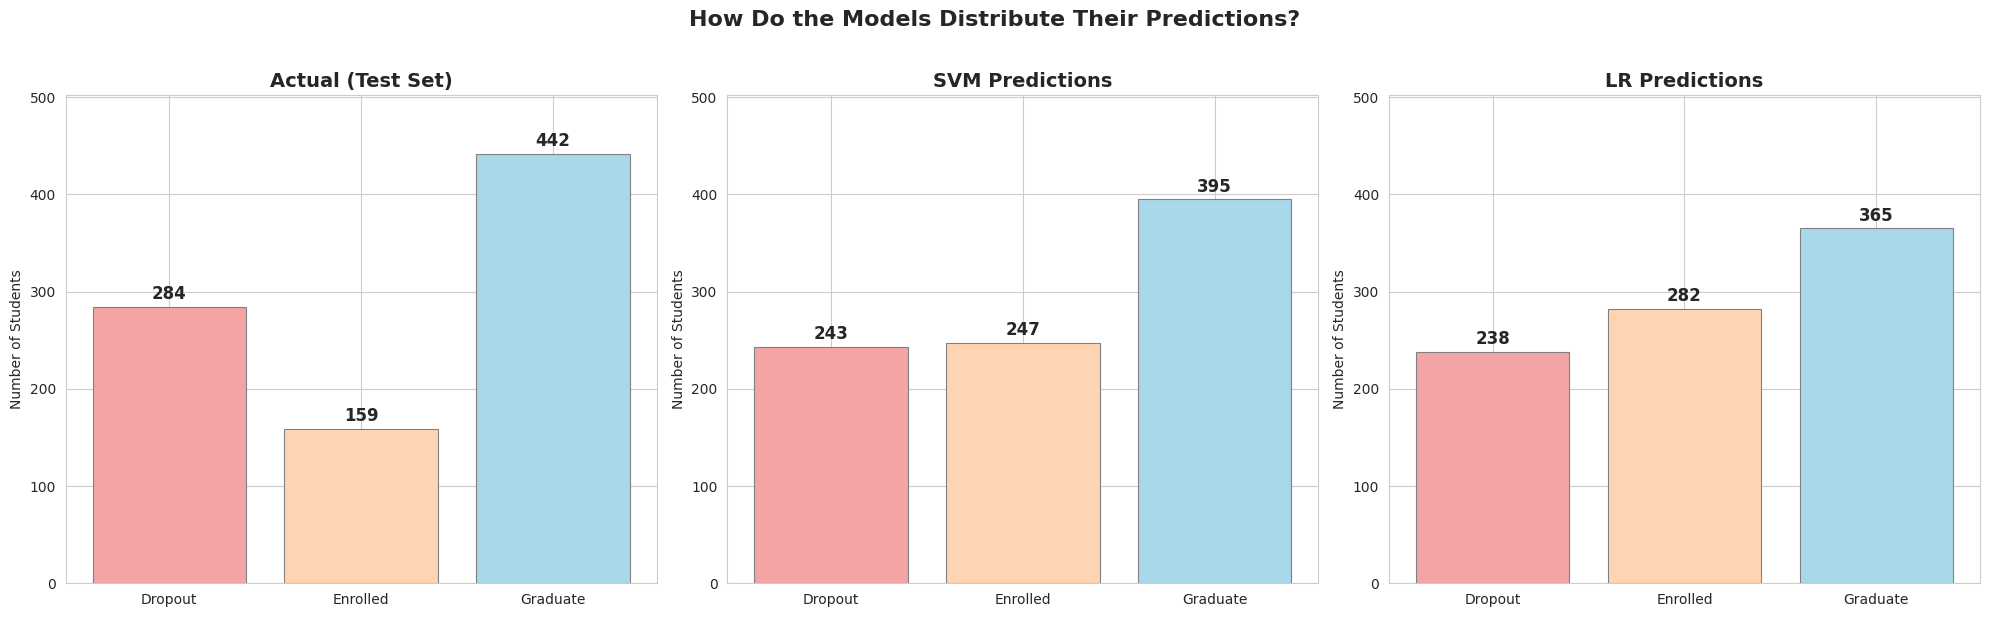

In [ ]:
# How do the models distribute their predictions vs reality?
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
class_names = ['Dropout', 'Enrolled', 'Graduate']
pastel = ['#F4A4A4', '#FFD4B2', '#A8D8EA']

actual_counts = [sum(y_test == i) for i in range(3)]
svm_counts = [sum(y_pred_svm == i) for i in range(3)]
lr_counts = [sum(y_pred_lr == i) for i in range(3)]

for ax, counts, title in zip(axes, [actual_counts, svm_counts, lr_counts],
                              ['Actual (Test Set)', 'SVM Predictions', 'LR Predictions']):
    ax.bar(class_names, counts, color=pastel, edgecolor='grey', linewidth=0.8)
    for i, v in enumerate(counts):
        ax.text(i, v + 8, str(v), ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_ylabel('Number of Students')
    ax.set_ylim(0, max(actual_counts) + 60)

plt.suptitle('How Do the Models Distribute Their Predictions?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'prediction_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

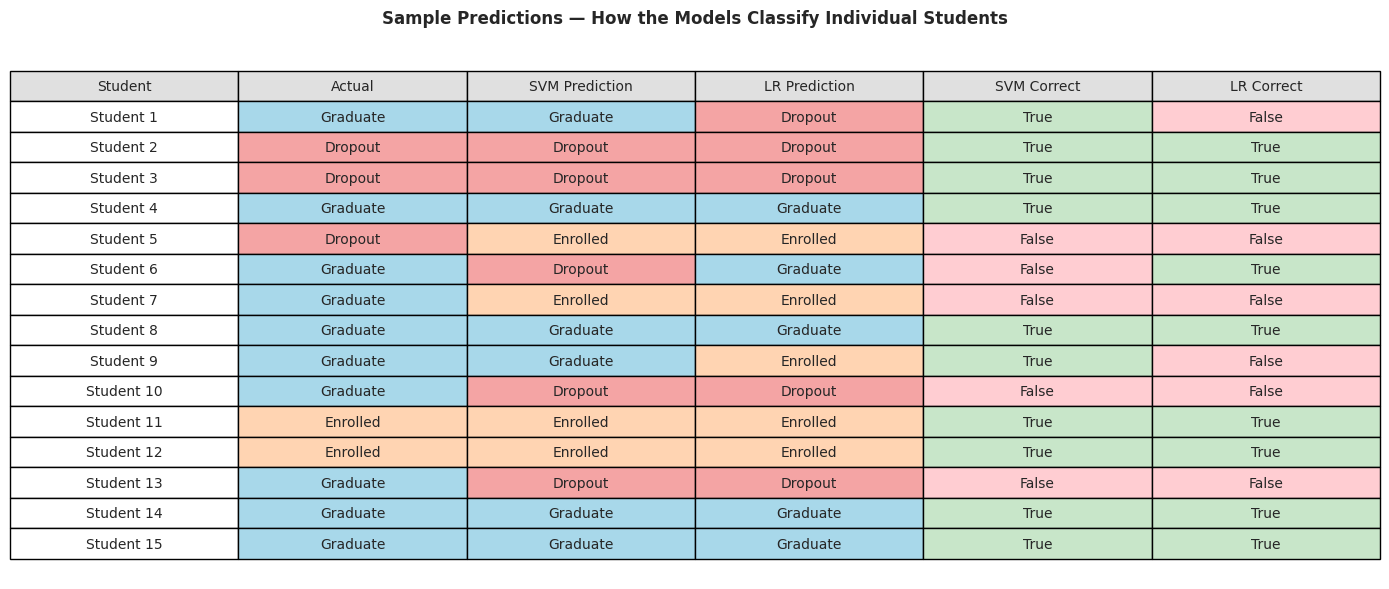

In [ ]:
# Sample of 15 individual predictions
np.random.seed(42)
sample_idx = np.random.choice(len(y_test), 15, replace=False)
label_map = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}

sample_df = pd.DataFrame({
    'Student': [f'Student {i+1}' for i in range(15)],
    'Actual': [label_map[y_test.iloc[j]] for j in sample_idx],
    'SVM Prediction': [label_map[y_pred_svm[j]] for j in sample_idx],
    'LR Prediction': [label_map[y_pred_lr[j]] for j in sample_idx],
})
sample_df['SVM Correct'] = sample_df['Actual'] == sample_df['SVM Prediction']
sample_df['LR Correct'] = sample_df['Actual'] == sample_df['LR Prediction']

# Colour-coded table
fig, ax = plt.subplots(figsize=(14, 6))
ax.axis('off')
colors_map = {'Dropout': '#F4A4A4', 'Enrolled': '#FFD4B2', 'Graduate': '#A8D8EA'}
cell_colours = []
for _, row in sample_df.iterrows():
    cell_colours.append([
        '#FFFFFF', colors_map[row['Actual']], colors_map[row['SVM Prediction']],
        colors_map[row['LR Prediction']],
        '#C8E6C9' if row['SVM Correct'] else '#FFCDD2',
        '#C8E6C9' if row['LR Correct'] else '#FFCDD2',
    ])
table = ax.table(cellText=sample_df.values, colLabels=sample_df.columns,
                 cellColours=cell_colours, colColours=['#E0E0E0']*6,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.6)
ax.set_title('Sample Predictions — How the Models Classify Individual Students', fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_DIR, 'sample_predictions.png'), dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save my results as a separate file — teammates do the same in their notebooks
# Comparison notebook collects all files later

RESULTS_DIR = os.path.join(PROJECT_DIR, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)

my_results = pd.DataFrame([
    {
        'member': 'Neha',
        'model': 'SVM',
        'model_type': 'unique',
        'best_params': str(svm_grid.best_params_),
        'accuracy': accuracy_score(y_test, y_pred_svm),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_svm),
        'macro_f1': f1_score(y_test, y_pred_svm, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred_svm, average='weighted'),
        'roc_auc': svm_auc,
        'dropout_f1': f1_score(y_test, y_pred_svm, average=None)[0],
        'enrolled_f1': f1_score(y_test, y_pred_svm, average=None)[1],
        'graduate_f1': f1_score(y_test, y_pred_svm, average=None)[2],
    },
    {
        'member': 'Neha',
        'model': 'Logistic Regression',
        'model_type': 'shared',
        'best_params': str(lr_grid.best_params_),
        'accuracy': accuracy_score(y_test, y_pred_lr),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_lr),
        'macro_f1': f1_score(y_test, y_pred_lr, average='macro'),
        'weighted_f1': f1_score(y_test, y_pred_lr, average='weighted'),
        'roc_auc': lr_auc,
        'dropout_f1': f1_score(y_test, y_pred_lr, average=None)[0],
        'enrolled_f1': f1_score(y_test, y_pred_lr, average=None)[1],
        'graduate_f1': f1_score(y_test, y_pred_lr, average=None)[2],
    },
])

results_path = os.path.join(RESULTS_DIR, 'results_neha.csv')
my_results.to_csv(results_path, index=False)

print(f'Saved to: {results_path}')
print(my_results[['member', 'model', 'balanced_accuracy', 'macro_f1', 'roc_auc']].to_string(index=False))

Saved to: /content/drive/MyDrive/COMM074_Project/results/results_neha.csv
member               model  balanced_accuracy  macro_f1  roc_auc
  Neha                 SVM           0.582516  0.570711 0.760317
  Neha Logistic Regression           0.557288  0.544742 0.757970


## 9. Discussion

### SVM
The big jump from baseline to tuned (~0.50 to ~0.58 balanced accuracy) was mostly down to the grid search figuring out that class_weight='balanced' was needed. Without it the model was basically ignoring Enrolled students because there's so few of them compared to Graduate. Best setup turned out to be RBF kernel, C=1, gamma=0.01.

Looking at the per-class numbers, SVM does best on Graduate which isn't surprising since that's the biggest group. Enrolled is the tough one — precision is only about 0.34 which means when the model says someone will stay enrolled it's wrong more often than it's right. Makes sense though, Enrolled students are kind of in limbo, they could go either way.

The cross-validation scores were very stable (std of ~0.002) which means the model behaves consistently across different data splits. The learning curve shows validation scores levelling off around 2000 training samples, suggesting we're close to the ceiling for what these features can tell us.

SVM's weakness is that it can't explain itself. If a student advisor asks "why was this person flagged" there's no straightforward answer.

### Logistic Regression
Similar story here — balanced weights helped, and lower regularisation (C=0.01) worked best. The scores aren't far off SVM which is interesting, suggests the patterns in this data might be more linear than we expected.

Where LR wins is that you can actually look at the coefficients and see what's going on. The feature importance plot shows tuition fees, admission grade, and age coming up as top predictors consistently, which matches what we found during EDA. That kind of transparency matters if this were actually being used by a university.

### ROC-AUC
Both models hit around 0.76 macro ROC-AUC which is considerably better than the balanced accuracy numbers suggest. ROC-AUC measures how well the model ranks predictions (distinguishing between classes) rather than just whether the final hard prediction is right or wrong. This means the models are better at estimating risk than the accuracy numbers alone would suggest.

### Why the scores aren't higher
This is by design. We're only using features available at enrolment — demographics, application details, finances. The semester columns we dropped would almost certainly push things into the 70-80% range but then it's not really an early warning system anymore. You can't intervene early if the model needs to wait for exam results. Getting ~0.58 balanced accuracy from just enrolment data is a reasonable starting point for something that's meant to flag students on day one.

### Which one would we actually use?
Depends on the goal. SVM is slightly better at catching at-risk students overall. LR is better if the people using it need to understand and trust the output — you can show an advisor exactly which factors contributed to a flag. Realistically you'd probably want both running together.

## 10. Summary

| | SVM | Logistic Regression |
|---|---|---|
| Best Params | RBF, C=1, gamma=0.01, balanced | C=0.01, saga, balanced |
| Balanced Accuracy | ~0.58 | ~0.56 |
| Macro F1 | ~0.57 | ~0.55 |
| ROC-AUC (macro) | ~0.76 | ~0.76 |
| Improvement from tuning | +8.2% bal acc | +3.8% bal acc |
| CV stability (std) | ~0.002 | — |
| Interpretable? | No | Yes (coefficients) |
| Best at | Overall classification | Explaining predictions |

Both models identify tuition fees, scholarship status, and age as the strongest early warning signals. The recommendation for the report will be finalised once we compare all five team members' models.

## 11. References

- Dataset: Realinho, V. et al. (2022). Predict Students' Dropout and Academic Success. UCI Machine Learning Repository. https://doi.org/10.24432/C5MC89
- scikit-learn documentation: https://scikit-learn.org/stable/
- SVM implementation: sklearn.svm.SVC — https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html
- Logistic Regression: sklearn.linear_model.LogisticRegression — https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- GridSearchCV: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- CRISP-DM methodology as covered in Week 1 lecture, COM3032/COMM074
- SVM and Logistic Regression concepts from Week 5 and Week 7 lectures, COM3032/COMM074